In [1]:
import jupyter
import nbconvert
import numpy as np
import pandas as pd
from nbconvert.exporters import pdf

In [2]:
import os
print(os.path.exists('../data/processed/train_optimized.pkl'))

True


In [3]:
train = pd.read_pickle('../data/processed/train_optimized.pkl')
print(train.shape)
print(f'{train.memory_usage(deep=True).sum():,}')

(590540, 434)
953,877,651


In [4]:
from sklearn.model_selection import train_test_split
X = train.drop(columns=['isFraud', 'TransactionID'])
y = train['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [5]:
print(X_train.shape, X_test.shape,)
print(y_train.mean(), y_test.mean())

(472432, 432) (118108, 432)
0.03498916246147594 0.0349933958749619


In [6]:
print(472432/590540, 118108/590540)

0.8 0.2


In [7]:
baseline_predictions = pd.Series(0, index=y_test.index)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
print("Baseline accuracy: ", accuracy_score(y_test, baseline_predictions))
print("Baseline Recall: ", recall_score(y_test, baseline_predictions))
print("Baseline Precision: ", precision_score(y_test, baseline_predictions))
print("Baseline F1: ", f1_score(y_test, baseline_predictions))

Baseline accuracy:  0.9650066041250381
Baseline Recall:  0.0
Baseline Precision:  0.0
Baseline F1:  0.0


C:\Users\moizs\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [8]:
cat_cols = X_train.select_dtypes(include=['category']).columns
print(cat_cols)
print("total cat columns: ", len(cat_cols))

Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15',
       'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33',
       'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType',
       'DeviceInfo'],
      dtype='str')
total cat columns:  31


In [9]:
for col in cat_cols:
    print(col, X_train[col].nunique())

ProductCD 5
card4 4
card6 4
P_emaildomain 59
R_emaildomain 60
M1 2
M2 2
M3 2
M4 3
M5 2
M6 2
M7 2
M8 2
M9 2
id_12 2
id_15 3
id_16 2
id_23 3
id_27 2
id_28 2
id_29 2
id_30 75
id_31 124
id_33 236
id_34 4
id_35 2
id_36 2
id_37 2
id_38 2
DeviceType 2
DeviceInfo 1686


In [10]:
high_card_cols = ['P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33', 'DeviceInfo']
low_card_cols = [col for col in cat_cols if col not in high_card_cols]

print(len(high_card_cols), len(low_card_cols))
print(high_card_cols)

6 25
['P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33', 'DeviceInfo']


In [11]:
from sklearn.preprocessing import LabelEncoder
#label encoding for high-card columns
for col in high_card_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))

    known_classes = set(le.classes_)
    X_test[col] = X_test[col].astype(str).apply(lambda x: x if x in known_classes else 'UNKNOWN')
    le.classes_ = np.append(le.classes_, 'UNKNOWN')
    X_test[col] = le.transform(X_test[col])

X_train = pd.get_dummies(X_train, columns=low_card_cols)
X_test = pd.get_dummies(X_test, columns=low_card_cols)
print(X_train.shape, X_test.shape)



(472432, 469) (118108, 469)


In [12]:
print(set(X_train.columns) == set(X_test.columns))

True


In [13]:
unseen_mask = X_test['DeviceInfo'] == 'UNKNOWN'
print(unseen_mask.sum(), "out of", len(X_test))

0 out of 118108


In [14]:
unknown_code = le.transform(['UNKNOWN'])[0]
print((X_test['DeviceInfo'] == unknown_code).sum(), "out of", len(X_test))

116 out of 118108


In [15]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
y_pred = model.predict(X_test)
print("Model accuracy: ", accuracy_score(y_test, y_pred))
print("Model recall: ", recall_score(y_test, y_pred))
print("Model precision: ", precision_score(y_test, y_pred))
print("Model f1: ", f1_score(y_test, y_pred))

Model accuracy:  0.9795780133437193
Model recall:  0.4420517783692233
Model precision:  0.9451629591308847
Model f1:  0.6023738872403561


In [17]:
model_v2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
model_v2.fit(X_train, y_train)

y_pred_v2 = model_v2.predict(X_test)
print("Precision:", precision_score(y_test, y_pred_v2))
print("Recall:", recall_score(y_test, y_pred_v2))
print("Precision:", precision_score(y_test, y_pred_v2))
print("F1:", f1_score(y_test, y_pred_v2))

Precision: 0.9487612612612613
Recall: 0.4076941688845875
Precision: 0.9487612612612613
F1: 0.5703164664071755


In [18]:
print("Original model fraud predictions: ", y_pred.sum())
print("class_weight model fraud predictions: ", y_pred_v2.sum())
print("Original fraud in test: ", y_test.sum())

Original model fraud predictions:  1933
class_weight model fraud predictions:  1776
Original fraud in test:  4133


In [19]:
y_proba = model.predict_proba(X_test)[:, 1]
print(y_proba[:10])

[0.   0.03 0.01 0.   0.   0.01 0.   0.   0.   0.  ]


threshold = 0.3:\
Recall:  0.5862569562061457\
Precision:  0.8188577222034471\
F1:  0.6833051325437112\
threshold = 0.25:\
Recall:  0.6319864505202032\
Precision:  0.7635194387605964\
F1:  0.6915541435001323\
threshold = 0.2:\
Recall:  0.679893539801597\
Precision:  0.6748318924111432\
F1:  0.6773532602145353\
threshold = 0.15:\
Recall:  0.731913864021292\
Precision:  0.5373001776198935\
F1:  0.6196865717504866

In [20]:
threshold = 0.25
y_pred_threshold = (y_proba >= threshold).astype(int)
print("Recall: ", recall_score(y_test, y_pred_threshold))
print("Precision: ", precision_score(y_test, y_pred_threshold))
print("F1: ", f1_score(y_test, y_pred_threshold))

Recall:  0.6319864505202032
Precision:  0.7635194387605964
F1:  0.6915541435001323


In [21]:
train['trans_day'] = (train['TransactionDT'] // 86400).astype(np.int16)
train['trans_hour'] = ((train['TransactionDT'] % 86400) // 3600).astype(np.int8)
train['trans_weekday'] = (train['trans_day'] % 7).astype(np.int8)

print(train[['TransactionDT', 'trans_day', 'trans_hour', 'trans_weekday']].head(10))

   TransactionDT  trans_day  trans_hour  trans_weekday
0          86400          1           0              1
1          86401          1           0              1
2          86469          1           0              1
3          86499          1           0              1
4          86506          1           0              1
5          86510          1           0              1
6          86522          1           0              1
7          86529          1           0              1
8          86535          1           0              1
9          86536          1           0              1


C:\Users\moizs\AppData\Local\Temp\ipykernel_16796\4064895839.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['trans_day'] = (train['TransactionDT'] // 86400).astype(np.int16)
C:\Users\moizs\AppData\Local\Temp\ipykernel_16796\4064895839.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['trans_hour'] = ((train['TransactionDT'] % 86400) // 3600).astype(np.int8)
C:\Users\moizs\AppData\Local\Temp\ipykernel_16796\4064895839.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calli

In [22]:
X_train[['trans_day', 'trans_hour', 'trans_weekday']] = train.loc[X_train.index, ['trans_day', 'trans_hour', 'trans_weekday']]
X_test[['trans_day', 'trans_hour', 'trans_weekday']] = train.loc[X_test.index, ['trans_day', 'trans_hour', 'trans_weekday']]

C:\Users\moizs\AppData\Local\Temp\ipykernel_16796\4052196821.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[['trans_day', 'trans_hour', 'trans_weekday']] = train.loc[X_train.index, ['trans_day', 'trans_hour', 'trans_weekday']]
C:\Users\moizs\AppData\Local\Temp\ipykernel_16796\4052196821.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[['trans_day', 'trans_hour', 'trans_weekday']] = train.loc[X_test.index, ['trans_day', 'trans_hour', 'trans_weekday']]


In [23]:
print(X_train[['trans_day', 'trans_hour', 'trans_weekday']].shape)
print(X_test[['trans_day', 'trans_hour', 'trans_weekday']].shape)

(472432, 3)
(118108, 3)


In [24]:
print(X_train[['trans_day', 'trans_hour', 'trans_weekday']].head())
print(X_test[['trans_day', 'trans_hour', 'trans_weekday']].head())

        trans_day  trans_hour  trans_weekday
40809          11          16              4
285886         81           2              4
104256         23          23              2
507860        153          22              6
196382         51           1              2
        trans_day  trans_hour  trans_weekday
316078         91           0              0
116888         26           3              5
410211        119          22              0
251027         69           3              6
191265         49          17              0


In [25]:
print(X_train.shape, X_test.shape)

(472432, 472) (118108, 472)


`RandomForest Model 1:`\
Model accuracy:  0.9795780133437193\
Model recall:  0.4420517783692233\
Model precision:  0.9451629591308847\
Model f1:  0.6023738872403561\
`RandomForest Model 2(Balanced Class):`\
Recall: 0.4076941688845875\
Precision: 0.9487612612612613\
F1: 0.5703164664071755

In [26]:
model_v3 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_v3.fit(X_train, y_train)

y_pred_v3 = model_v3.predict(X_test)


In [27]:
print("Model accuracy: ", accuracy_score(y_test, y_pred_v3))
print("Model Recall:", recall_score(y_test, y_pred_v3))
print("Model precision:", precision_score(y_test, y_pred_v3))
print("F1 Score:", f1_score(y_test, y_pred_v3))

Model accuracy:  0.9795441460358316
Model Recall: 0.44180982337285263
Model precision: 0.9436692506459948
F1 Score: 0.6018457481872116


In [28]:
y_proba_v3 = model_v3.predict_proba(X_test)[:, 1]
y_pred_v3_thresh = (y_proba_v3 >= 0.25).astype(int)

print("Recall:", recall_score(y_test, y_pred_v3_thresh))
print("Precision:", precision_score(y_test, y_pred_v3_thresh))
print("F1:", f1_score(y_test, y_pred_v3_thresh))

Recall: 0.6324703605129446
Precision: 0.7672439095978867
F1: 0.693368700265252


In [29]:
import lightgbm as gbm
print(gbm.__version__)

4.6.0


In [30]:
import re

X_train.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in X_train.columns]
X_test.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in X_test.columns]

print(X_train.shape, X_test.shape)

(472432, 472) (118108, 472)


In [31]:
model_gbm = gbm.LGBMClassifier(n_estimators=1000, num_leaves=31, learning_rate=0.05, random_state=42, n_jobs=-1, is_unbalance=True)
model_gbm.fit(X_train, y_train, eval_set=[(X_test, y_test)])

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.798843 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 39302
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 467
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [32]:
y_pred_gbm = model_gbm.predict(X_test)

In [33]:
print("Accuracy: ", accuracy_score(y_test, y_pred_gbm))
print("Recall: ", recall_score(y_test, y_pred_gbm))
print("Precision: ", precision_score(y_test, y_pred_gbm))
print("F1: ", f1_score(y_test, y_pred_gbm))

Accuracy:  0.9398939953263115
Recall:  0.8429712073554319
Precision:  0.35071471713307834
F1:  0.49534371223430723


In [34]:
y_proba_gbm = model_gbm.predict_proba(X_test)[:, 1]
print(y_proba_gbm.describe() if hasattr(y_proba_gbm, 'describe') else pd.Series(y_proba_gbm).describe())

count    118108.000000
mean          0.165272
std           0.210161
min           0.000002
25%           0.031306
50%           0.083005
75%           0.204440
max           0.999942
dtype: float64


In [35]:
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]

for thresh in thresholds:
    preds = (y_proba_gbm >= thresh).astype(int)
    r = recall_score(y_test, preds)
    p = precision_score(y_test, preds)
    f = f1_score(y_test, preds)
    print(f"thresh={thresh:.2f} | Recall={r:.3f} | Precision={p:.3f} | F1={f:.3f}")

thresh=0.10 | Recall=0.979 | Precision=0.077 | F1=0.142
thresh=0.15 | Recall=0.961 | Precision=0.102 | F1=0.184
thresh=0.20 | Recall=0.949 | Precision=0.130 | F1=0.229
thresh=0.25 | Recall=0.932 | Precision=0.159 | F1=0.272
thresh=0.30 | Recall=0.916 | Precision=0.191 | F1=0.316
thresh=0.40 | Recall=0.879 | Precision=0.262 | F1=0.404
thresh=0.50 | Recall=0.843 | Precision=0.351 | F1=0.495


In [36]:
model_gbm_v2 = gbm.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model_gbm_v2.fit(X_train, y_train, eval_set=[(X_test, y_test)])

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.017943 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 39302
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 467
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [37]:
y_proba_lgb_v2 = model_gbm_v2.predict_proba(X_test)[:, 1]

thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]

for thresh in thresholds:
    preds = (y_proba_lgb_v2 >= thresh).astype(int)
    r = recall_score(y_test, preds)
    p = precision_score(y_test, preds)
    f = f1_score(y_test, preds)
    print(f"thresh={thresh:.2f} | Recall={r:.3f} | Precision={p:.3f} | F1={f:.3f}")

thresh=0.10 | Recall=0.788 | Precision=0.567 | F1=0.660
thresh=0.15 | Recall=0.742 | Precision=0.703 | F1=0.722
thresh=0.20 | Recall=0.704 | Precision=0.784 | F1=0.742
thresh=0.25 | Recall=0.673 | Precision=0.841 | F1=0.748
thresh=0.30 | Recall=0.644 | Precision=0.884 | F1=0.745
thresh=0.40 | Recall=0.589 | Precision=0.923 | F1=0.719
thresh=0.50 | Recall=0.539 | Precision=0.946 | F1=0.687


In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

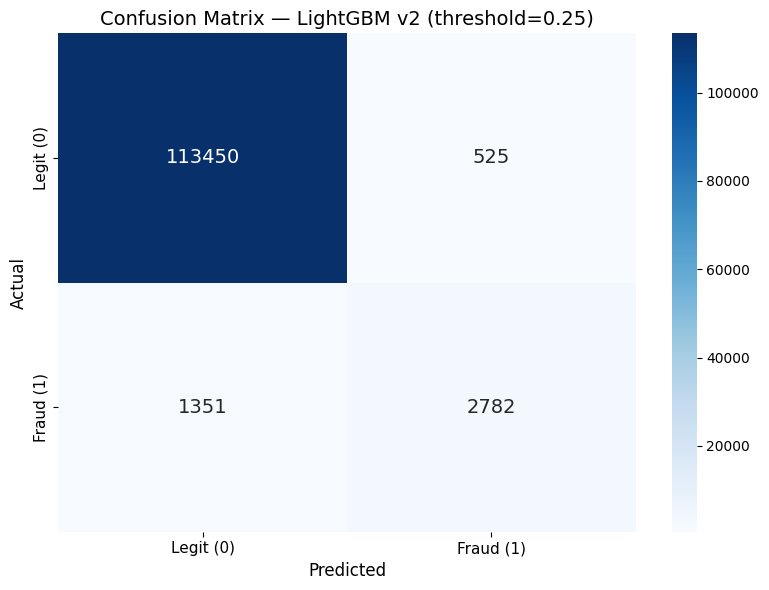

True Negatives  (legit correctly caught): 113,450
False Positives (legit wrongly flagged):  525
False Negatives (fraud missed):           1,351
True Positives  (fraud correctly caught): 2,782

Of 4,133 actual fraud cases, caught 2,782 (67.3%)
Of 3,307 fraud flags, 2,782 were real (84.1% precision)


In [39]:

plt.style.use('default')
y_pred_lgb_025 = (y_proba_lgb_v2 >= 0.25).astype(int)
cm = confusion_matrix(y_test, y_pred_lgb_025)

labels = ['Legit (0)', 'Fraud (1)']
plt.figure(figsize=(8, 6), facecolor='white')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14})
plt.title('Confusion Matrix — LightGBM v2 (threshold=0.25)', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Print raw interpretation
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (legit correctly caught): {tn:,}")
print(f"False Positives (legit wrongly flagged):  {fp:,}")
print(f"False Negatives (fraud missed):           {fn:,}")
print(f"True Positives  (fraud correctly caught): {tp:,}")
print(f"\nOf {tp+fn:,} actual fraud cases, caught {tp:,} ({tp/(tp+fn)*100:.1f}%)")
print(f"Of {tp+fp:,} fraud flags, {tp:,} were real ({tp/(tp+fp)*100:.1f}% precision)")

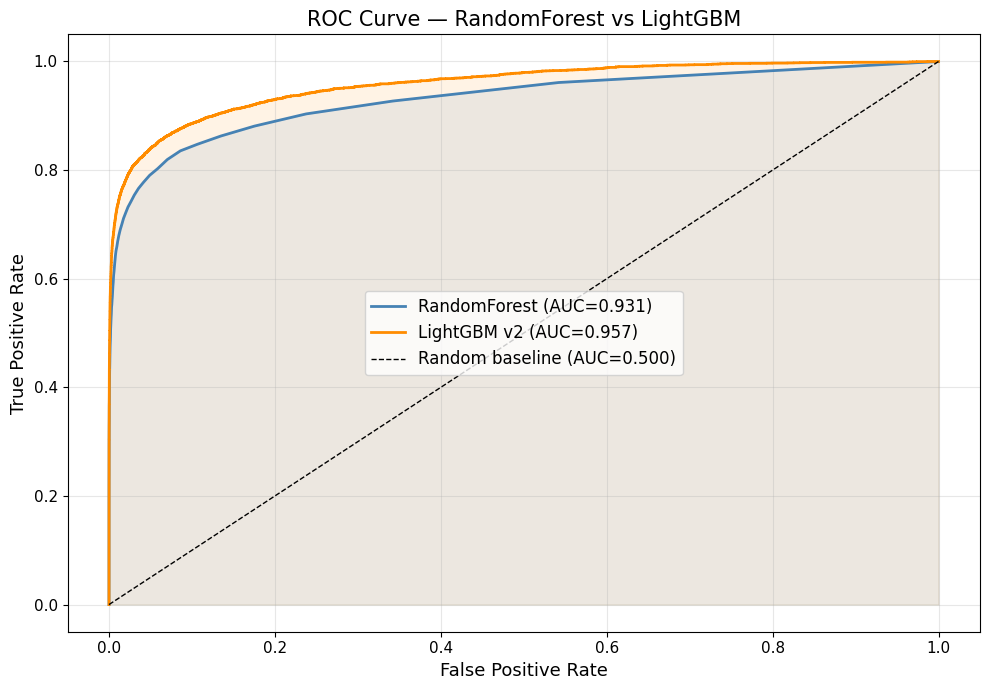

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

rf_fpr, rf_tpr, _ = roc_curve(y_test, y_proba)
lgb_fpr, lgb_tpr, _ = roc_curve(y_test, y_proba_lgb_v2)

rf_auc = roc_auc_score(y_test, y_proba)
lgb_auc = roc_auc_score(y_test, y_proba_lgb_v2)

plt.figure(figsize=(10, 7), facecolor='white')
plt.plot(rf_fpr, rf_tpr, color='steelblue', linewidth=2,
         label=f'RandomForest (AUC={rf_auc:.3f})')
plt.plot(lgb_fpr, lgb_tpr, color='darkorange', linewidth=2,
         label=f'LightGBM v2 (AUC={lgb_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random baseline (AUC=0.500)')
plt.fill_between(lgb_fpr, lgb_tpr, alpha=0.1, color='darkorange')
plt.fill_between(rf_fpr, rf_tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('ROC Curve — RandomForest vs LightGBM', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.style.use('default')
plt.tight_layout()
plt.show()

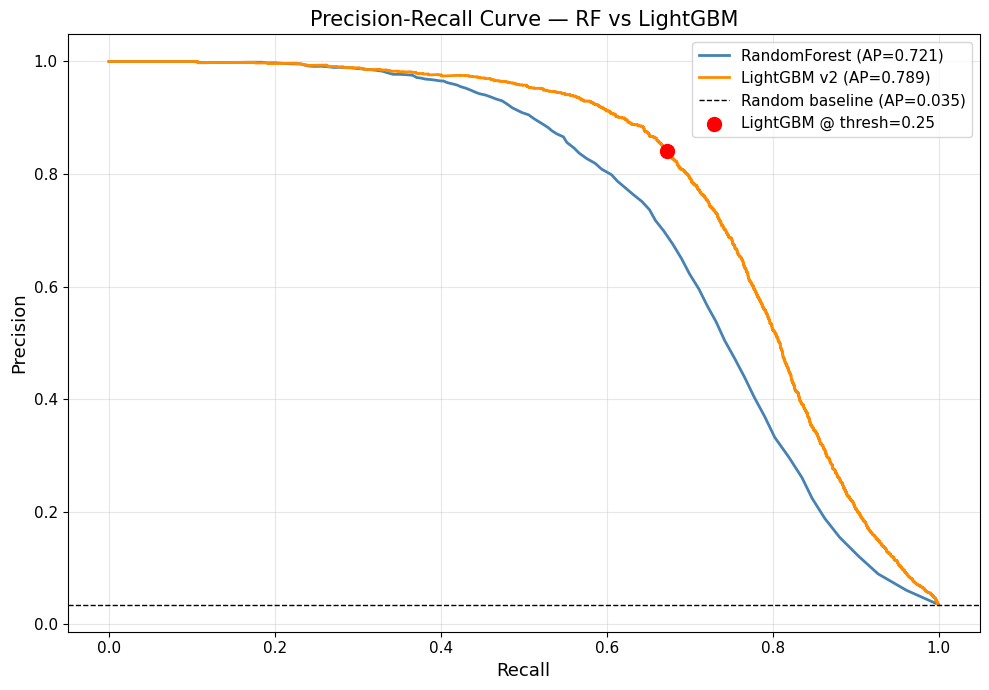

In [41]:
plt.style.use('default')
from sklearn.metrics import precision_recall_curve, average_precision_score

rf_prec, rf_rec, _ = precision_recall_curve(y_test, y_proba)
lgb_prec, lgb_rec, _ = precision_recall_curve(y_test, y_proba_lgb_v2)

rf_ap = average_precision_score(y_test, y_proba)
lgb_ap = average_precision_score(y_test, y_proba_lgb_v2)

plt.figure(figsize=(10, 7), facecolor='white')
plt.plot(rf_rec, rf_prec, color='steelblue', linewidth=2,
         label=f'RandomForest (AP={rf_ap:.3f})')
plt.plot(lgb_rec, lgb_prec, color='darkorange', linewidth=2,
         label=f'LightGBM v2 (AP={lgb_ap:.3f})')
plt.axhline(y=0.035, color='k', linestyle='--', linewidth=1,
            label='Random baseline (AP=0.035)')

# mark your chosen threshold on LightGBM curve
plt.scatter([0.673], [0.841], color='red', zorder=5, s=100,
            label='LightGBM @ thresh=0.25')

plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Precision-Recall Curve — RF vs LightGBM', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

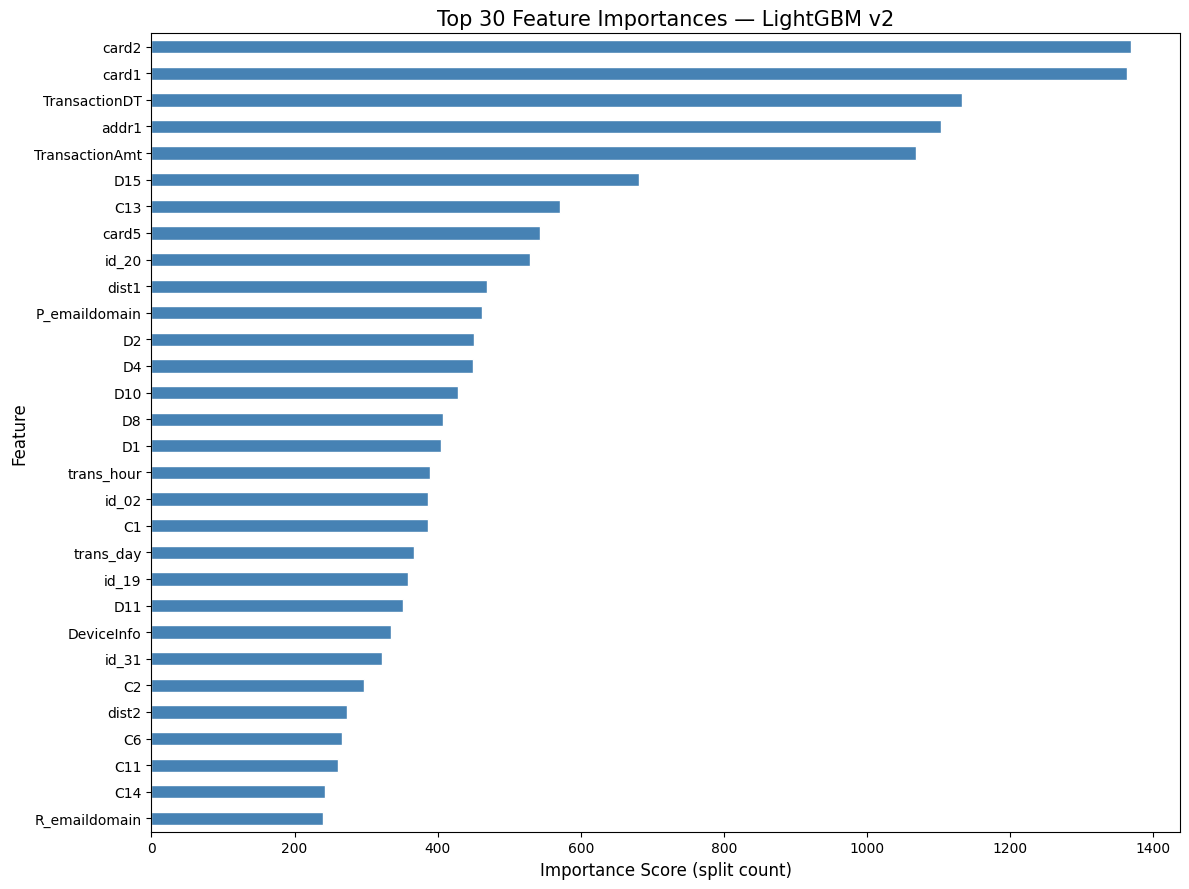


Top 10 features:
card2             1369
card1             1363
TransactionDT     1133
addr1             1103
TransactionAmt    1069
D15                682
C13                571
card5              543
id_20              529
dist1              469
dtype: int32


In [42]:
plt.style.use('default')
feat_imp = pd.Series(
    model_gbm_v2.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(30)

plt.figure(figsize=(12, 9), facecolor='white')
feat_imp.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 30 Feature Importances — LightGBM v2', fontsize=15)
plt.xlabel('Importance Score (split count)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feat_imp.head(10))

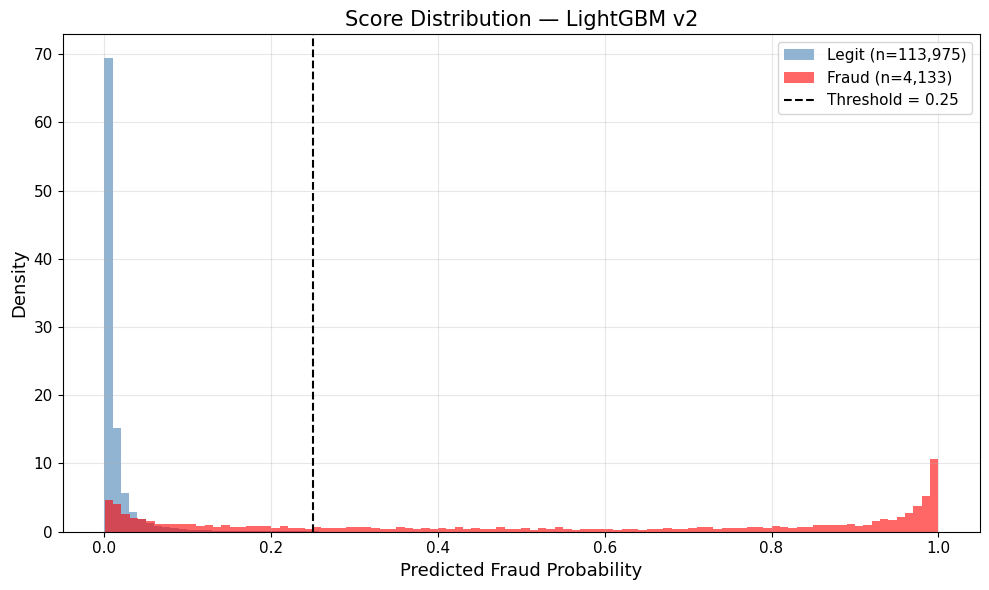

In [43]:
plt.style.use('default')
fraud_probs = y_proba_lgb_v2[y_test == 1]
legit_probs = y_proba_lgb_v2[y_test == 0]

plt.figure(figsize=(10, 6), facecolor='white')
plt.hist(legit_probs, bins=100, alpha=0.6, color='steelblue',
         label=f'Legit (n={len(legit_probs):,})', density=True)
plt.hist(fraud_probs, bins=100, alpha=0.6, color='red',
         label=f'Fraud (n={len(fraud_probs):,})', density=True)
plt.axvline(x=0.25, color='black', linestyle='--', linewidth=1.5,
            label='Threshold = 0.25')
plt.xlabel('Predicted Fraud Probability', fontsize=13)
plt.ylabel('Density', fontsize=13)
plt.title('Score Distribution — LightGBM v2', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()